# Linear Regression

# Using Tensors and Autograd

In [1]:
import torch

importamos el dataset

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42) #por defecto tiene 0.25 de test_size
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

convertimos a tensores y normalizamos

In [3]:
X_train=torch.FloatTensor(X_train)
X_valid=torch.FloatTensor(X_valid)
X_test=torch.FloatTensor(X_test)
means=X_train.mean(dim=0, keepdims=True)
stds=X_train.std(dim=0, keepdims=True)
X_train=(X_train-means)/stds
X_valid=(X_valid-means)/stds
X_test=(X_test-means)/stds

convertimos las targets a tensores, y le hacemos reshape para que se vuelca un vector columna

In [4]:
y_train=torch.FloatTensor(y_train).reshape(-1,1) #el -1 es para que pytorch calcule automaticamente el numero de filas
y_valid=torch.FloatTensor(y_valid).reshape(-1,1)
y_test=torch.FloatTensor(y_test).reshape(-1,1)

In [5]:
y_train

tensor([[1.4420],
        [1.6870],
        [1.6210],
        ...,
        [0.6800],
        [0.6130],
        [1.9700]])

creamos los parametros de nuestro modelo de regresion lineal

In [6]:
torch.manual_seed(42)
n_features=X_train.shape[1] #hay 8 features de entrada
w=torch.randn((n_features,1),requires_grad=True) #weight
b=torch.tensor(0.,requires_grad=True) #bias

## entrenamos el moldelo (usamos bacth gradient descent(BGD))
- primero definimos el learning rate
- despues corremos 20 epocas
- despues calculamos la prediccion (y_pred) y el mean square error para el loss
- entonces corremos loss.backward()  para calcular los gradientes de el loss con respecto a cada parametro del modelo
- usamos los gradientes b.grad y w.grad para hacer el gradiente descent step dentro de torch.no_grad()
- una vez que hicimos el gradient descent step reseteamos los gradientes a zero(importante)
- y por ultimo imprimimos el numero de la epoca y el loss de cada epoca. el metodo item() extrae el valor de un tesnor escalar

In [7]:
learning_rate=0.4
n_epochs=20
for epoch in range(n_epochs):
  y_pred=X_train @ w + b
  loss=((y_pred-y_train)**2).mean()
  loss.backward()
  with torch.no_grad():
    b-=learning_rate * b.grad
    w-=learning_rate * w.grad
    b.grad.zero_()
    w.grad.zero_()
  print(f"epoch {epoch+1}/{n_epochs}, loss: {loss.item()}")

epoch 1/20, loss: 16.158456802368164
epoch 2/20, loss: 4.8793745040893555
epoch 3/20, loss: 2.255225419998169
epoch 4/20, loss: 1.3307634592056274
epoch 5/20, loss: 0.9680691957473755
epoch 6/20, loss: 0.8142675757408142
epoch 7/20, loss: 0.7417045831680298
epoch 8/20, loss: 0.7020701169967651
epoch 9/20, loss: 0.6765918731689453
epoch 10/20, loss: 0.6577965021133423
epoch 11/20, loss: 0.6426151990890503
epoch 12/20, loss: 0.6297222971916199
epoch 13/20, loss: 0.6184942126274109
epoch 14/20, loss: 0.6085968613624573
epoch 15/20, loss: 0.5998216867446899
epoch 16/20, loss: 0.592018723487854
epoch 17/20, loss: 0.5850691795349121
epoch 18/20, loss: 0.578873336315155
epoch 19/20, loss: 0.573345422744751
epoch 20/20, loss: 0.5684100389480591


hagamos prediccion de las tres primeras instancias  del test set

In [8]:
X_new=X_test[:3] #pretendemos que son nuevas instancias
with torch.no_grad():
  y_pred=X_new @ w + b #usamos los parametros entrenados para hacer predicciones
y_pred

tensor([[0.8916],
        [1.6480],
        [2.6577]])

# Using Pytorch's High-Level API

pytorch tiene una implementacion de la regresion lineal en la clase torch.nn.linear

In [9]:
import torch.nn as nn #por convencion este modulo usualmente se importa de esta manera

torch.manual_seed(42)
model=nn.Linear(in_features=n_features,out_features=1)

In [10]:
model.bias

Parameter containing:
tensor([0.3117], requires_grad=True)

In [11]:
model.weight

Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True)

ahora que el modelo esta creado, necesitamos crear un optimizador que actualice los parametros del modelo, y debemos escoger una funcion de loss

In [12]:
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
mse=nn.MSELoss()

funcion para entrenar a nuestro modelo
- en pytorch loss function es normalmente referida como criterion para distingirlos de el valor de loss
- el optimizer.step() corresponde a las dos lineas que actualizaban b y w
- optimizer.zero_grad() corresponde a las dos lineas que hacian cero b.grad y w.grad. Aca no necesitamos usar torch.no_grad(), porque eso lo hace automaticamente el optimizer

In [13]:
def train_bgd(model,optimizer,criterion,X_train,y_train,n_epochs):
  for epoch in range(n_epochs):
    y_pred=model(X_train)
    loss=criterion(y_pred,y_train)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"epoch {epoch+1}/{n_epochs}, loss: {loss.item()}")

llamamos a la funcion para entrenar el modelo

In [14]:
train_bgd(model,optimizer,mse,X_train,y_train,n_epochs)

epoch 1/20, loss: 4.3378496170043945
epoch 2/20, loss: 0.7802939414978027
epoch 3/20, loss: 0.6253842115402222
epoch 4/20, loss: 0.6060433983802795
epoch 5/20, loss: 0.5956299304962158
epoch 6/20, loss: 0.587356686592102
epoch 7/20, loss: 0.5802990794181824
epoch 8/20, loss: 0.5741382837295532
epoch 9/20, loss: 0.5687101483345032
epoch 10/20, loss: 0.5639079809188843
epoch 11/20, loss: 0.5596511363983154
epoch 12/20, loss: 0.5558737516403198
epoch 13/20, loss: 0.5525194406509399
epoch 14/20, loss: 0.5495392084121704
epoch 15/20, loss: 0.5468900203704834
epoch 16/20, loss: 0.544533908367157
epoch 17/20, loss: 0.5424376726150513
epoch 18/20, loss: 0.5405716300010681
epoch 19/20, loss: 0.5389097332954407
epoch 20/20, loss: 0.5374288558959961


probamos el modelo

In [15]:
X_new=X_test[:3]
with torch.no_grad():
  y_pred=model(X_new)
y_pred

tensor([[0.8061],
        [1.7116],
        [2.6973]])

# Implementing a Regression MLP
### capas
1. la primera capa debe tener el mismo numero de inputs de nuestros datos(n_features). Sin embargo puede tener cualquiero numero de ouputs
2. tenemos una funcion ReLU que implementa la activacion ReLU a la primera capa
3. la segunda capa oculta debe tener el mismo numero de inputs que los outputs de la capa anterior. Sin embargo puede tener cualquiere cantidad de outputs
4. Otra vez nn.ReLU para implementar la funcion de activacion a la segunda capa oculta
5. finalmente la capa de salida debe tener los mismos inputs que ouputs de la capa anterior. Pero esta vez el numero de ouputs tiene que se igual que la dimension de targets

In [16]:

torch.manual_seed(42)
#capas de nuestro modelo
model=nn.Sequential(
    nn.Linear(n_features,50),
    nn.ReLU(),
    nn.Linear(50,40),
    nn.ReLU(),
    nn.Linear(40,1)
)

entrenemos el modelo como lo hicimos antes

In [17]:
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)


epoch 1/20, loss: 5.045480251312256
epoch 2/20, loss: 2.0523123741149902
epoch 3/20, loss: 1.0039883852005005
epoch 4/20, loss: 0.8570139408111572
epoch 5/20, loss: 0.7740675210952759
epoch 6/20, loss: 0.7225847244262695
epoch 7/20, loss: 0.6893726587295532
epoch 8/20, loss: 0.6669032573699951
epoch 9/20, loss: 0.6507738828659058
epoch 10/20, loss: 0.6383934020996094
epoch 11/20, loss: 0.6281993389129639
epoch 12/20, loss: 0.6193399429321289
epoch 13/20, loss: 0.6113173365592957
epoch 14/20, loss: 0.6038705706596375
epoch 15/20, loss: 0.5968307852745056
epoch 16/20, loss: 0.5901119112968445
epoch 17/20, loss: 0.5836468935012817
epoch 18/20, loss: 0.5774063467979431
epoch 19/20, loss: 0.5713554620742798
epoch 20/20, loss: 0.565444827079773


# Implementing Mini-Batch Gradient Descent Using DataLoaders

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train,y_train)
batch_s=32
train_loader=DataLoader(train_dataset,batch_size=batch_s,shuffle=True)



usamos la aceleracion de hardware

In [19]:
if torch.cuda.is_available():
    device="cuda"
    print("Using GPU")
elif torch.backends.mps.is_available():
    device="mps"
    print("Using MPS")
else:
    device="cpu"
    print("Using CPU")

Using GPU


In [20]:
torch.manual_seed(42)
model=nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 1)
)

model=model.to(device)
# extra code – build the optimizer and loss function, as earlier
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()


creamos funcion de entrenamineto para implementar mini-bacth GD

In [21]:
def train(model,optimizer,criterion,train_loader,n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss=0.
    for X_batch,y_batch in train_loader:
      X_batch, y_batch=X_batch.to(device), y_batch.to(device)
      y_pred=model(X_batch)
      loss=criterion(y_pred,y_batch)
      total_loss+=loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    mean_loss=total_loss/len(train_loader)
    print(f"epoch {epoch+1}/{n_epochs}, loss: {mean_loss:.4f}")

entrenamos el modelo

In [22]:
train(model,optimizer,mse,train_loader,n_epochs)

epoch 1/20, loss: 0.5900
epoch 2/20, loss: 0.4046
epoch 3/20, loss: 0.3801
epoch 4/20, loss: 0.3629
epoch 5/20, loss: 0.3529
epoch 6/20, loss: 0.3520
epoch 7/20, loss: 0.3408
epoch 8/20, loss: 0.3427
epoch 9/20, loss: 0.3406
epoch 10/20, loss: 0.3378
epoch 11/20, loss: 0.3304
epoch 12/20, loss: 0.3267
epoch 13/20, loss: 0.3243
epoch 14/20, loss: 0.3221
epoch 15/20, loss: 0.3187
epoch 16/20, loss: 0.3148
epoch 17/20, loss: 0.3121
epoch 18/20, loss: 0.3110
epoch 19/20, loss: 0.3088
epoch 20/20, loss: 0.3069


# Modelo Evaluation

In [23]:
def evaluate(model,data_loader,metric_fn,aggregate_fn=torch.mean):
  model.eval()
  metrics=[]
  with torch.no_grad():
    for X_batch,y_batch in data_loader:
      X_batch, y_batch=X_batch.to(device), y_batch.to(device)
      y_pred=model(X_batch)
      metric=metric_fn(y_pred,y_batch)
      metrics.append(metric.item())
  return aggregate_fn(torch.tensor(metrics))

construimos un TensorDataset y un DataLoader para nuestro set de validacion y lo pasamos a nuestra funcion evaluate() para calcular la validacion MSE

In [24]:
valid_dataset=TensorDataset(X_valid,y_valid)
valid_loader=DataLoader(valid_dataset,batch_size=batch_s)
valid_mse=evaluate(model,valid_loader,mse)
valid_mse


tensor(0.4016)

ahora supongamos que queremos usa RMSE en vez de MSE. Pytorch no tiene una funcion para eso pero se puede hacer asi

In [25]:
def rmse(y_pred,y_true):
  return ((y_pred-y_true)**2).mean().sqrt()

In [26]:
evaluate(model,valid_loader,rmse)

tensor(0.5655)

es mejor usar MSE y unsar aggregate_fn para clacular la raiz cuadrada de MSE

In [27]:
evaluate(model,valid_loader,mse,aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(0.6337)

pytorch tiene su propia libreria TorchMetrics
(no está preinstalada en colab asi que la instalamos con %pip install torchmetrics)

In [28]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.8 MB/s eta 0:00:00


In [29]:
import torchmetrics

def evaluate_tm(model,data_loader,metrics):
  model.eval()
  metrics.reset() #reset the metrics at the beginning
  with torch.no_grad():
    for X_batch,y_batch in data_loader:
      X_batch, y_batch=X_batch.to(device), y_batch.to(device)
      y_pred=model(X_batch)
      metrics.update(y_pred,y_batch) #updates in each iteration
  return metrics.compute() #compute the final result at the end

entonces podemos crear RSME

In [30]:
rmse=torchmetrics.MeanSquaredError(squared=False).to(device)
evaluate_tm(model,valid_loader,rmse)

tensor(0.6338, device='cuda:0')

actualizando la funcion de entrenamineto para ver el performance en el training set y el validation set

Epoch 1/20, train loss: 0.7826, train metric: 0.8847, valid metric: 0.6690
Epoch 2/20, train loss: 0.4362, train metric: 0.6605, valid metric: 0.6099
Epoch 3/20, train loss: 0.3930, train metric: 0.6269, valid metric: 0.6145
Epoch 4/20, train loss: 0.3759, train metric: 0.6132, valid metric: 0.5963
Epoch 5/20, train loss: 0.3649, train metric: 0.6040, valid metric: 0.5911
Epoch 6/20, train loss: 0.3598, train metric: 0.5999, valid metric: 0.5965
Epoch 7/20, train loss: 0.3530, train metric: 0.5941, valid metric: 0.6062
Epoch 8/20, train loss: 0.3495, train metric: 0.5911, valid metric: 0.6043
Epoch 9/20, train loss: 0.3454, train metric: 0.5877, valid metric: 0.5723
Epoch 10/20, train loss: 0.3416, train metric: 0.5845, valid metric: 0.6037
Epoch 11/20, train loss: 0.3400, train metric: 0.5830, valid metric: 0.5880
Epoch 12/20, train loss: 0.3362, train metric: 0.5799, valid metric: 0.5738
Epoch 13/20, train loss: 0.3352, train metric: 0.5788, valid metric: 0.5881
Epoch 14/20, train lo

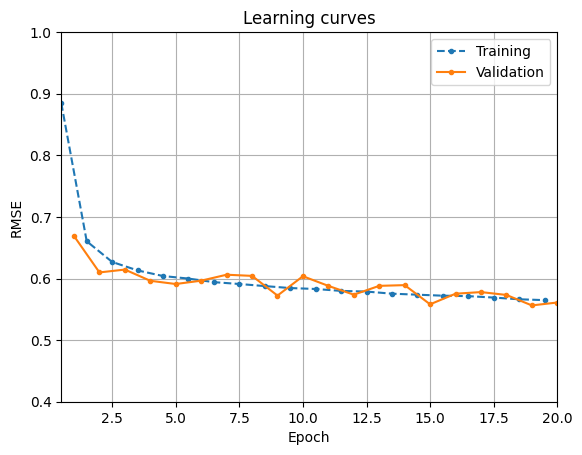

In [31]:
import matplotlib.pyplot as plt
import numpy as np
def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

# Since we compute the training metric
plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

# Building Nonsquential Models Using Custom Modules
creamos una clase derivada de torch.nn.Module, entonces creamos todas las capas que necesitemos en el constructor(__init__()) y definimos como se deben usar esas capas en el modulo en el metodo forward()

In [32]:
class WideAndDeep(nn.Module):
  def __init__(self,n_features):
     super().__init__()
     self.deep_stack=nn.Sequential(
         nn.Linear(n_features,50), nn.ReLU(),
         nn.Linear(50,40), nn.ReLU()
     )
     self.output_layer=nn.Linear(40+n_features,1)

  def forward(self,X):
    deep_ouput=self.deep_stack(X)
    wide_and_deep=torch.concat([X,deep_ouput],dim=1)
    return self.output_layer(wide_and_deep)

In [33]:
torch.manual_seed(42)
model=WideAndDeep(n_features).to(device)
learning_rate=0.002
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
mse=nn.MSELoss()
history=train2(model,optimizer,mse,rmse,train_loader,valid_loader,n_epochs)


Epoch 1/20, train loss: 1.4093, train metric: 1.1873, valid metric: 0.8794
Epoch 2/20, train loss: 0.6105, train metric: 0.7815, valid metric: 0.8410
Epoch 3/20, train loss: 0.5624, train metric: 0.7500, valid metric: 0.7263
Epoch 4/20, train loss: 0.5267, train metric: 0.7256, valid metric: 0.7730
Epoch 5/20, train loss: 0.5050, train metric: 0.7105, valid metric: 0.7300
Epoch 6/20, train loss: 0.4800, train metric: 0.6929, valid metric: 0.6787
Epoch 7/20, train loss: 0.4648, train metric: 0.6819, valid metric: 0.6950
Epoch 8/20, train loss: 0.4505, train metric: 0.6711, valid metric: 0.6437
Epoch 9/20, train loss: 0.4397, train metric: 0.6631, valid metric: 0.7005
Epoch 10/20, train loss: 0.4309, train metric: 0.6564, valid metric: 0.6289
Epoch 11/20, train loss: 0.4227, train metric: 0.6502, valid metric: 0.6604
Epoch 12/20, train loss: 0.4161, train metric: 0.6451, valid metric: 0.6223
Epoch 13/20, train loss: 0.4097, train metric: 0.6402, valid metric: 0.6729
Epoch 14/20, train lo

pero si quieres enviar un subset de features a travez de wide pah y un diferente subset a travez del deeo path

In [34]:
class WideAndDeepV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self, X):
        X_wide = X[:, :5]
        X_deep = X[:, 2:]
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        return self.output_layer(wide_and_deep)

# Building Models with Multiple Inputs
algunos modelos requieren multiples inputs que no pueden combinarse facilmente en un solo tensor. Por ejemplo el input puede tener un diferente numero de dimensiones(ejm: quiere poner imagenes y texto dentro de la red neuronal)

cambiamos el metodo forward()

In [35]:
class WideAndDeepV3(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)

    def forward(self,X_wide,X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)

        return self.output_layer(wide_and_deep)

ahora creamos datasets que retornen wide and deeps inputs separados

In [36]:
torch.manual_seed(42)
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

In [37]:
def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train_multi_in(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd,
                         valid_loader_wd, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

In [38]:
class WideAndDeepDataset(torch.utils.data.Dataset):
    def __init__(self, X_wide, X_deep, y):
        self.X_wide = X_wide
        self.X_deep = X_deep
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        input_dict = {"X_wide": self.X_wide[idx], "X_deep": self.X_deep[idx]}
        return input_dict, self.y[idx]

In [39]:

torch.manual_seed(42)
train_data_named = WideAndDeepDataset(
    X_wide=X_train[:, :5], X_deep=X_train[:, 2:], y=y_train)
train_loader_named = DataLoader(train_data_named, batch_size=32, shuffle=True)
valid_data_named = WideAndDeepDataset(
    X_wide=X_valid[:, :5], X_deep=X_valid[:, 2:], y=y_valid)
valid_loader_named = DataLoader(valid_data_named, batch_size=32)
test_data_named = WideAndDeepDataset(
    X_wide=X_test[:, :5], X_deep=X_test[:, 2:], y=y_test)
test_loader_named = DataLoader(test_data_named, batch_size=32)

In [40]:
def evaluate_named(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(X_wide=inputs["X_wide"], X_deep=inputs["X_deep"])
            metric.update(y_pred, y_batch)
    return metric.compute()  # compute the final result at the end

def train_named(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred = model(**inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_named(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_named(model, optimizer, mse, rmse, train_loader_named,
                      valid_loader_named, n_epochs)

Epoch 1/20, train loss: 0.8366, train metric: 0.9148, valid metric: 0.6892
Epoch 2/20, train loss: 0.4627, train metric: 0.6803, valid metric: 0.6455
Epoch 3/20, train loss: 0.4319, train metric: 0.6572, valid metric: 0.6374
Epoch 4/20, train loss: 0.4259, train metric: 0.6525, valid metric: 0.6512
Epoch 5/20, train loss: 0.4120, train metric: 0.6420, valid metric: 0.6305
Epoch 6/20, train loss: 0.4040, train metric: 0.6356, valid metric: 0.6287
Epoch 7/20, train loss: 0.4005, train metric: 0.6330, valid metric: 0.6252
Epoch 8/20, train loss: 0.3976, train metric: 0.6306, valid metric: 0.6158
Epoch 9/20, train loss: 0.3883, train metric: 0.6230, valid metric: 0.7407
Epoch 10/20, train loss: 0.3866, train metric: 0.6218, valid metric: 0.6063
Epoch 11/20, train loss: 0.3752, train metric: 0.6125, valid metric: 0.5974
Epoch 12/20, train loss: 0.3704, train metric: 0.6087, valid metric: 0.5887
Epoch 13/20, train loss: 0.3677, train metric: 0.6063, valid metric: 0.5981
Epoch 14/20, train lo

# Building Models with Multiple Outputs

In [41]:
class WideAndDeepV4(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.deep_stack = nn.Sequential(
            nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
        )
        self.output_layer = nn.Linear(30 + 5, 1)
        self.aux_output_layer = nn.Linear(30, 1)

    def forward(self, X_wide, X_deep):
        deep_output = self.deep_stack(X_deep)
        wide_and_deep = torch.concat([X_wide, deep_output], dim=1)
        main_output = self.output_layer(wide_and_deep)
        aux_output = self.aux_output_layer(deep_output)
        return main_output, aux_output

In [42]:
import torchmetrics

def evaluate_multi_out(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for inputs, y_batch in data_loader:
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, _ = model(**inputs)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train_multi_out(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for inputs, y_batch in train_loader:
            model.train()
            inputs = {name: X.to(device) for name, X in inputs.items()}
            y_batch = y_batch.to(device)
            y_pred, y_pred_aux = model(**inputs)
            main_loss = criterion(y_pred, y_batch)
            aux_loss = criterion(y_pred_aux, y_batch)
            loss = 0.8 * main_loss + 0.2 * aux_loss
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_out(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV4(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_out(model, optimizer, mse, rmse, train_loader_named,
                          valid_loader_named, n_epochs)

Epoch 1/20, train loss: 1.0693, train metric: 0.9506, valid metric: 0.7085
Epoch 2/20, train loss: 0.5817, train metric: 0.6946, valid metric: 0.6607
Epoch 3/20, train loss: 0.5010, train metric: 0.6581, valid metric: 0.6425
Epoch 4/20, train loss: 0.4690, train metric: 0.6497, valid metric: 0.6654
Epoch 5/20, train loss: 0.4503, train metric: 0.6420, valid metric: 0.6338
Epoch 6/20, train loss: 0.4387, train metric: 0.6373, valid metric: 0.6563
Epoch 7/20, train loss: 0.4315, train metric: 0.6330, valid metric: 0.6193
Epoch 8/20, train loss: 0.4249, train metric: 0.6302, valid metric: 0.6167
Epoch 9/20, train loss: 0.4116, train metric: 0.6202, valid metric: 0.6450
Epoch 10/20, train loss: 0.4085, train metric: 0.6198, valid metric: 0.5938
Epoch 11/20, train loss: 0.4073, train metric: 0.6196, valid metric: 0.5959
Epoch 12/20, train loss: 0.3914, train metric: 0.6077, valid metric: 0.6074
Epoch 13/20, train loss: 0.3847, train metric: 0.6033, valid metric: 0.5813
Epoch 14/20, train lo

# Building an Image Classifier with Pytorch

## Using TorchVisicon to Load the Dataset

Vamos a cargar Fashion MNIST el cual ay esta separado en training set(60.000 imagenes) y test set(10.000 imagenes) pero vamos a usar las ultimas 5.000 imagenes del training set para validacion usndo la funcion de Pytorch random_split()

In [43]:
import torchvision
import torchvision.transforms.v2 as T


In [44]:
toTensor=T.Compose([T.ToImage(),T.ToDtype(torch.float32,scale=True)])

train_and_valid_data=torchvision.datasets.FashionMNIST(root="datasets",train=True,download=True,transform=toTensor)
test_data=torchvision.datasets.FashionMNIST(root="datasets",train=False,download=True,transform=toTensor)

torch.manual_seed(42)
train_data,valid_data=torch.utils.data.random_split(train_and_valid_data,[55000,5000])

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


creamos los dataloaders

In [45]:
train_loader=DataLoader(train_data,batch_size=32,shuffle=True)
valid_loader=DataLoader(valid_data,batch_size=32)
test_loader=DataLoader(test_data,batch_size=32)

miremos a la primer imagen del training set

las imagenes en un tensor tienen 3 dimensiones. La primera dimension es la channel dimension. Para imagenes en escala de grises solo hay un canal(imagenes a color normalmente tienen 3 canales). Las otras dos dimensiones son la altura(height) y el ancho(width).

In [46]:
X_sample,y_sample=train_data[0]
X_sample.shape

torch.Size([1, 28, 28])

In [47]:
X_sample.dtype

torch.float32

los targets son enteros desde 0 a 9. FashionMNIST tiene un atributo que contiene la lista de nombres. Por ejemplo aqui podemos mostrar que la imagen d emuestra es una ankle boot

In [48]:
train_and_valid_data.classes[y_sample]

'Ankle boot'

## Building the Classifier
construimos un modulo para clasificacion MLP con 2 capas ocultas

- el modelo empieza con nn.Flatten(): esta capa no tienen ningun parametro, solo convierte cada input en una sola dimension la cual es necesaria para las capas de nn.Linear
- la primera hidden layer debe tener el numero correcto de inputs(28x28=784), y la ouput layer debe tener el numero correcto de ouputs(10,uno por clase)
- usamos la funcion de activacion ReLU depues de cada capa oculta, y no la usamos depues de la capa de salida(ouput layer)
- como es una clasificacion multiclase usamos nn.CrossEntropyLoss

In [49]:
class ImageClassifier(nn.Module):
  def __init__(self,n_inputs,n_hidden1,n_hidden2,n_classes):
     super().__init__()

     self.mlp=nn.Sequential(
         nn.Flatten(), # Flatten() convierte un tensor multidimensional (como una matriz o imagen en 3D de ancho, alto y canales) en un vector unidimensional (1D)
         nn.Linear(n_inputs,n_hidden1), nn.ReLU(),
         nn.Linear(n_hidden1,n_hidden2), nn.ReLU(),
         nn.Linear(n_hidden2,n_classes)
     )

  def forward(self,X):
    return self.mlp(X)



In [50]:
torch.manual_seed(42)
model=ImageClassifier(n_inputs=28*28,n_hidden1=300,n_hidden2=100,n_classes=10)
model=model.to(device)
xentropy=nn.CrossEntropyLoss()

para evaluar el modelo podemos usar Accuracy streaming metrix de la libreria torchmetrics y moverla a la GPU

In [51]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
train2(model, optimizer, xentropy, accuracy, train_loader, valid_loader,
           n_epochs)

Epoch 1/20, train loss: 0.6058, train metric: 0.7816, valid metric: 0.8416
Epoch 2/20, train loss: 0.4059, train metric: 0.8497, valid metric: 0.8372
Epoch 3/20, train loss: 0.3633, train metric: 0.8663, valid metric: 0.8530
Epoch 4/20, train loss: 0.3359, train metric: 0.8762, valid metric: 0.8660
Epoch 5/20, train loss: 0.3147, train metric: 0.8835, valid metric: 0.8754
Epoch 6/20, train loss: 0.2991, train metric: 0.8881, valid metric: 0.8666
Epoch 7/20, train loss: 0.2859, train metric: 0.8916, valid metric: 0.8622
Epoch 8/20, train loss: 0.2745, train metric: 0.8971, valid metric: 0.8722
Epoch 9/20, train loss: 0.2639, train metric: 0.9007, valid metric: 0.8834
Epoch 10/20, train loss: 0.2531, train metric: 0.9041, valid metric: 0.8810
Epoch 11/20, train loss: 0.2463, train metric: 0.9068, valid metric: 0.8850
Epoch 12/20, train loss: 0.2353, train metric: 0.9109, valid metric: 0.8910
Epoch 13/20, train loss: 0.2303, train metric: 0.9125, valid metric: 0.8870
Epoch 14/20, train lo

{'train_losses': [0.6057984656012287,
  0.40589368286141136,
  0.3633476491885313,
  0.3359099991766952,
  0.31474672026017714,
  0.2991329276389234,
  0.28587268681794736,
  0.27447138163583473,
  0.2639402102759198,
  0.25307614425410707,
  0.24626984849080244,
  0.2353279979367496,
  0.23034648257976809,
  0.2235032835755326,
  0.21542639981027759,
  0.20885720256978235,
  0.20299648065358367,
  0.19893717235187203,
  0.1924224760201329,
  0.18878534975081873],
 'train_metrics': [0.7816181778907776,
  0.8497454524040222,
  0.8663091063499451,
  0.87616366147995,
  0.883472740650177,
  0.8880545496940613,
  0.8915636539459229,
  0.8971272706985474,
  0.9007090926170349,
  0.9041091203689575,
  0.9067999720573425,
  0.910909116268158,
  0.9124909043312073,
  0.9143636226654053,
  0.9184363484382629,
  0.9206545352935791,
  0.9234181642532349,
  0.9241636395454407,
  0.9271454811096191,
  0.9282181859016418],
 'valid_metrics': [0.8416000008583069,
  0.8371999859809875,
  0.852999985218

In [52]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
y_pred

tensor([7, 4, 2], device='cuda:0')

In [53]:
[train_and_valid_data.classes[index] for index in y_pred]


['Sneaker', 'Coat', 'Pullover']

si queremos que el modelo estime probabilidades, para eos necesitamos calcular softmax

In [54]:
import torch.nn.functional as F
y_proba=F.softmax(y_pred_logits,dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0010, 0.0000, 0.9110, 0.0000,
         0.0880],
        [0.0000, 0.0000, 0.0040, 0.0000, 0.9960, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.6250, 0.0000, 0.3350, 0.0000, 0.0390, 0.0000, 0.0000,
         0.0000]], device='cuda:0')

In [55]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
if device == "mps":
    y_top4_probas = y_top4_probas.cpu()
y_top4_probas.round(decimals=3)

tensor([[0.9110, 0.0880, 0.0010, 0.0000],
        [0.9960, 0.0040, 0.0000, 0.0000],
        [0.6250, 0.3350, 0.0390, 0.0000]], device='cuda:0')

In [56]:
y_top4_indices

tensor([[7, 9, 5, 8],
        [4, 2, 6, 0],
        [2, 4, 6, 0]], device='cuda:0')

# Fine-Tuning Neural Network Hyperparameters with Optuna

uptuna no viene instalado en colab asi que lo instalamos

In [57]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 24.9 MB/s eta 0:00:00


Primero necesitamos definir la funcion que Optuna va a llamar carias veces para ir cambiando los hiperparametros.

In [62]:
import optuna

def objective(trial):
  learning_rate=trial.suggest_float("learning_rate",1e-5,1e-1,log=True)
  n_hidden=trial.suggest_int("n_hidden",20,300)
  model=ImageClassifier(n_inputs=1*28*28,n_hidden1=n_hidden,n_hidden2=n_hidden,n_classes=10)
  model=model.to(device)
  optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)
  xentropy = nn.CrossEntropyLoss()
  accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
  accuracy = accuracy.to(device)
  history = train2(model, optimizer, xentropy, accuracy, train_loader,
                     valid_loader, n_epochs=10)
  validation_accuracy = max(history["valid_metrics"])
  return validation_accuracy


se demora mucho jajajajaja

In [63]:
torch.manual_seed(42)
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=5)

[I 2026-09-29 00:00:22,381] A new study created in memory with name: no-name-2136ec36-12ff-4e0a-8492-5eb8f4e9e348


Epoch 1/10, train loss: 2.2769, train metric: 0.1471, valid metric: 0.1860
Epoch 2/10, train loss: 2.2093, train metric: 0.2794, valid metric: 0.3500
Epoch 3/10, train loss: 2.1164, train metric: 0.4110, valid metric: 0.4554
Epoch 4/10, train loss: 1.9776, train metric: 0.5137, valid metric: 0.5562
Epoch 5/10, train loss: 1.7867, train metric: 0.5826, valid metric: 0.6026


[W 2026-09-29 00:02:02,266] Trial 0 failed with parameters: {'learning_rate': 0.00031489116479568613, 'n_hidden': 287} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_504/1863569958.py", line 12, in objective
    history = train2(model, optimizer, xentropy, accuracy, train_loader,
                       valid_loader, n_epochs=10)
  File "/tmp/ipykernel_504/2013583760.py", line 9, in train2
    for X_batch, y_batch in train_loader:
                            ^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 801, in _next_data
    data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
  File "/usr/loca

KeyboardInterrupt: 

In [ ]:
study.best_params

In [ ]:

study.best_value

# Saving and Loading a PyTorch Model
La manera mas simple de guardar un modelo de Pytorch es usar torch.save() pasando el modelo y la ruta de archivo. por convension se usa la extension .pt o .pth para archivos pytorch

In [64]:
torch.save(model,"my_fashion_mnist.pt")

ahora se puede cargar el modelo asi

In [66]:
loaded_model=torch.load("my_fashion_mnist.pt",weights_only=False)

In [67]:
loaded_model.eval()
y_pred_logits=loaded_model(X_new)

es recomendado guardar y cargar solo los pesos del modelo

In [71]:
torch.save(model.state_dict(),"my_fashion_mnist_weights.pt")

para cargar los pesos debemos primero crear un modelo con exactamente la misma etsructura. Entonces se cargan los pesos usando torch.load() con weights_only=True, y finalmente cargar el metodo del modelo load_state_dict() con los pesos cargados

In [72]:
new_model=ImageClassifier(n_inputs=1*28*28,n_hidden1=300,n_hidden2=100,n_classes=10)
loaded_weights=torch.load("my_fashion_mnist_weights.pt", weights_only=True)
new_model.load_state_dict(loaded_weights)
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

sol funciona si eres capaz de crear exactamente la misma arquitectura del modelo. Para eso necesitas el numero de neuronas por capa y es buena idea en guardar esta informacion con el state dictionary

In [73]:
model_data = {
    "model_state_dict": model.state_dict(),
    "model_hyperparameters": {
        "n_inputs": 1 * 28 * 28,
        "n_hidden1": 300,
        "n_hidden2": 100,
        "n_classes": 10,
    }
}
torch.save(model_data, "my_fashion_mnist_model.pt")

puedes cargar el diccionario, contruir el modelo basado en los hiperparametros guardados y cargar el state dictionary dentro de este modelo

In [74]:
loaded_data = torch.load("my_fashion_mnist_model.pt", weights_only=True)
new_model = ImageClassifier(**loaded_data["model_hyperparameters"])
new_model.load_state_dict(loaded_data["model_state_dict"])
new_model.eval()

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

# Compiling and Optimizing a PyTorch Model
se pueden convertir modelos a TorchScript

hay dos fromas de pasar mi modelo de pytorch a TorchScript. La primera es llamda tracing

In [ ]:
torchscript_model=torch.jit.trace(model,X_new)

la otra forma

In [75]:
torchscript_model=torch.jit.script(model)

se pueden guardar usando el metodo save

In [76]:
torchscript_model.save("my_fashion_mnist_torchscript.pt")

y se puede cargar usando la funcion torch.jit.load()

In [77]:
loaded_torchscript_model=torch.jit.load("my_fashion_mnist_torchscript.pt")

In [78]:
compiled_model=torch.compile(model)